In [ ]:
#Are there statistically significant effects for streamer gender, age, genre, and sentiment of the message on the frequency of 
#the 5 most frequently used unique emotes in emote-containing messages?
# Logistic Regression per emote, with streamer level clustered SE

In [1]:
import statsmodels.formula.api as smf
import pandas as pd
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import io
import numpy as np

df = pd.read_csv("/Users/inecuypers/Documents/DTA thesis/finals/df_sentiment_emotion_final.csv", index_col=0)
df.head(1)

,id,streamer,message,emotes,gender,age,genre,unique_emotes,total_emotes,sentiment,...,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,6b9fd713-82dc-4f76-90b3-a7d2f006e1ac,annacramling,Gg CoolCat,CoolCat,female,genz,nongaming,1,1,2,...,False,False,False,True,False,True,False,False,False,True


In [2]:
# 1. Convert strings to lists of emotes
df['emote_list'] = df['emotes'].fillna('').apply(lambda x: [e.strip() for e in str(x).split(',') if e.strip()])
#print(df['emote_list'])

# 3. Find Top 5 by MESSAGE APPEARANCE (Presence)
presence_emotes = [emote for sublist in df['emote_list'] for emote in set(sublist)]
#print(presence_emotes)
top_5_presence = pd.Series(presence_emotes).value_counts().head(5)

print("\nTop 5 Message Appearance:\n", top_5_presence)


Top 5 Message Appearance:
 LUL      841
<3       422
:)       240
Kappa    175
:D       141
Name: count, dtype: int64


In [3]:
# ensure categorical variables
df["gender"] = df["gender"].astype("category")
df["age"] = df["age"].astype("category")
df["genre"] = df["genre"].astype("category")
df['streamer'] = df['streamer'].astype('category').cat.codes
df["sentiment"] = df["sentiment"].map({
    0: 0,
    2: 1
})

In [6]:
target_emotes = top_5_presence.index.tolist()
model_comparison_1 = []

for emote in target_emotes:
    # Create binary dependent variable: 1 if emote in message, else 0
    df['target_present'] = df['emote_list'].apply(lambda x: 1 if emote in x else 0)
    
    # Fit the Interaction Model
    # Using Logit because the outcome is binary (Presence)
    model = smf.logit("target_present ~ C(sentiment) * gender * age * genre", data=df)
    
    # Cluster by streamer to account for community-level correlation
    try:
        results = model.fit(method='bfgs', maxiter=500, cov_type='cluster', cov_kwds={'groups': df['streamer']}, disp=0)

        current_aic = results.aic
        current_bic = results.bic
        
        print(f"\n--- Results for Emote: {emote} ---")
        print(f"AIC: {current_aic:.2f} | BIC: {current_bic:.2f}")
        
        # 2. Store for later comparison
        model_comparison_1.append({
            "emote": emote,
            "aic": current_aic,
            "bic": current_bic,
            "llf": results.llf  # Log-Likelihood (useful for LRT tests)
        })
        
        print(f"\n--- Results for Emote: {emote} ---")
        print(results.summary())
        
        # Exporting Odds Ratios for easier interpretation
        # OR > 1 means higher likelihood of usage
        odds_ratios = np.exp(results.params)
        print(f"Odds Ratios for {emote}:\n", odds_ratios)

        
    except Exception as e:
        print(f"Model for {emote} failed to converge: {e}")
    
        # --- A. Save LaTeX Table ---
    html_table = results.summary().tables[1].as_html()
    res_df = pd.read_html(io.StringIO(html_table), header=0, index_col=0)[0]
    
    # Clean filenames: replace special chars like <3 with 'heart' for saving
    safe_name = emote.replace("<3", "heart").replace(":)", "smile").replace(":(", "sad")
    res_df.to_latex(f"table_sentiment_presence_{safe_name}.tex", escape=False)
    
    # 2. --- Create Marginal Effects Plot ---
    # We need to create a grid that includes BOTH sentiment levels (0 and 1)
    # and all demographic combinations
    demographics = df[['gender', 'age', 'genre']].drop_duplicates()
    
    # Create two copies: one for Sentiment=0, one for Sentiment=1
    grid_neg = demographics.copy()
    grid_neg['sentiment'] = 0
    
    grid_pos = demographics.copy()
    grid_pos['sentiment'] = 1
    
    prediction_grid = pd.concat([grid_neg, grid_pos])
    
    # Predict probabilities
    prediction_grid['prob'] = results.predict(prediction_grid)
    
    # Map numeric sentiment back to labels for the plot legend
    prediction_grid['Sentiment_Label'] = prediction_grid['sentiment'].map({0: 'Negative', 1: 'Positive'})
    
    # 3. --- Visualization ---
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    # We use 'hue' for Sentiment now to see the "effect" of the sentiment
    # We use 'col' and 'row' to separate the demographics
    g = sns.catplot(
        data=prediction_grid, 
        x="gender", 
        y="prob", 
        hue="Sentiment_Label",  # This shows the interaction effect clearly
        col="genre", 
        row="age",              # Added row for age since we have 3 variables now
        kind="point", 
        capsize=.1, 
        height=4, 
        aspect=1
    )
    
    g.set_axis_labels("Gender", f"Prob. of '{emote}'")
    g.set_titles(template="{row_name} | {col_name}")
    g.fig.suptitle(f"Marginal Effects of Gender, Age, Genre, and Sentiment on Presence {emote}", y=1.02)

    
    plt.savefig(f"plot_sentiment_presence_{safe_name}.png", dpi=300, bbox_inches='tight')
    plt.close('all')


--- Results for Emote: LUL ---
AIC: 5039.36 | BIC: 5154.07

--- Results for Emote: LUL ---
                           Logit Regression Results                           
Dep. Variable:         target_present   No. Observations:                 9600
Model:                          Logit   Df Residuals:                     9584
Method:                           MLE   Df Model:                           15
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.1218
Time:                        15:15:31   Log-Likelihood:                -2503.7
converged:                       True   LL-Null:                       -2850.8
Covariance Type:              cluster   LLR p-value:                3.109e-138
                                                                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------


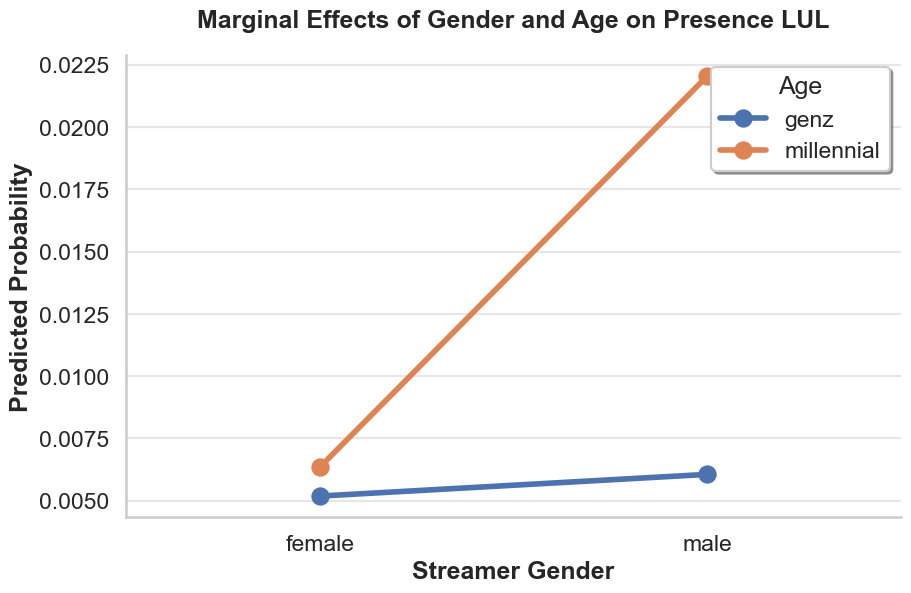

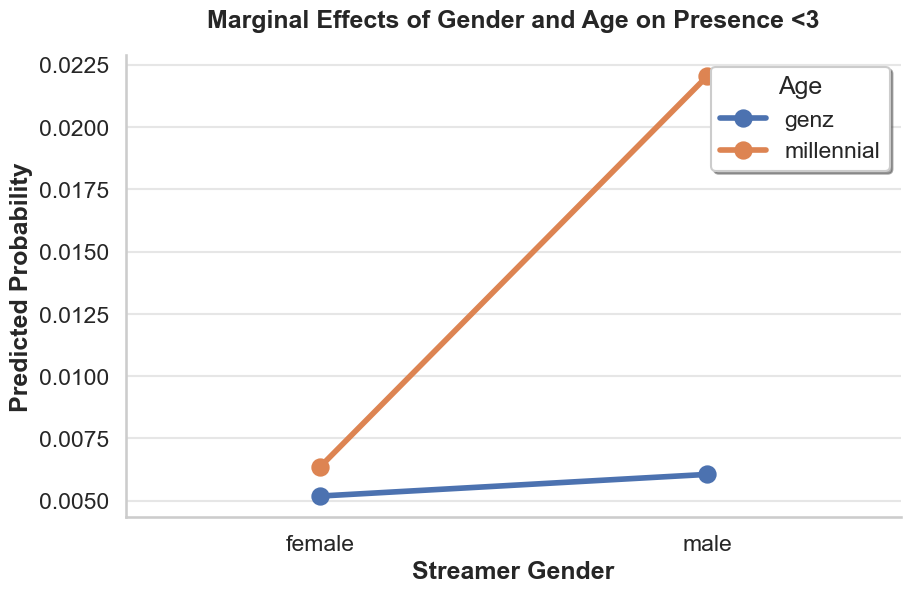

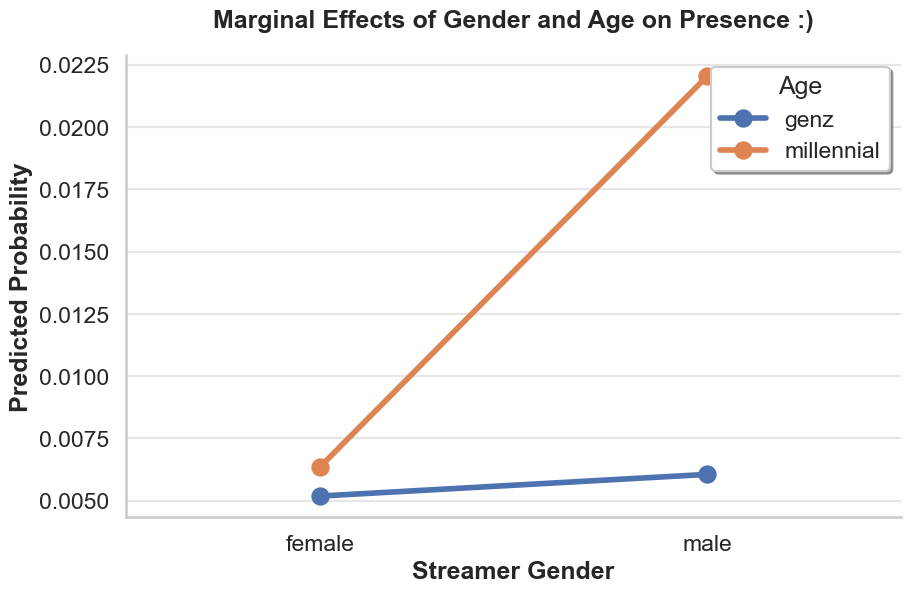

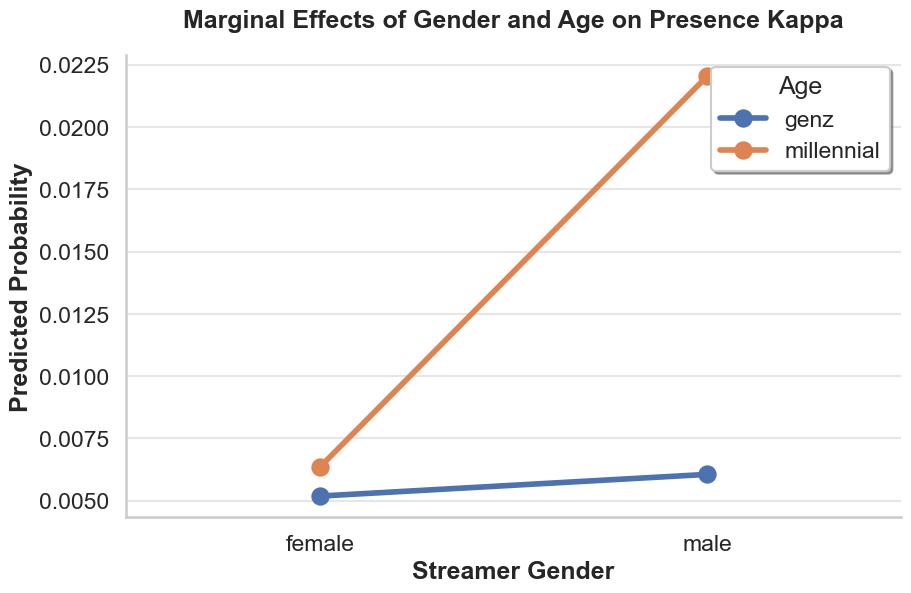

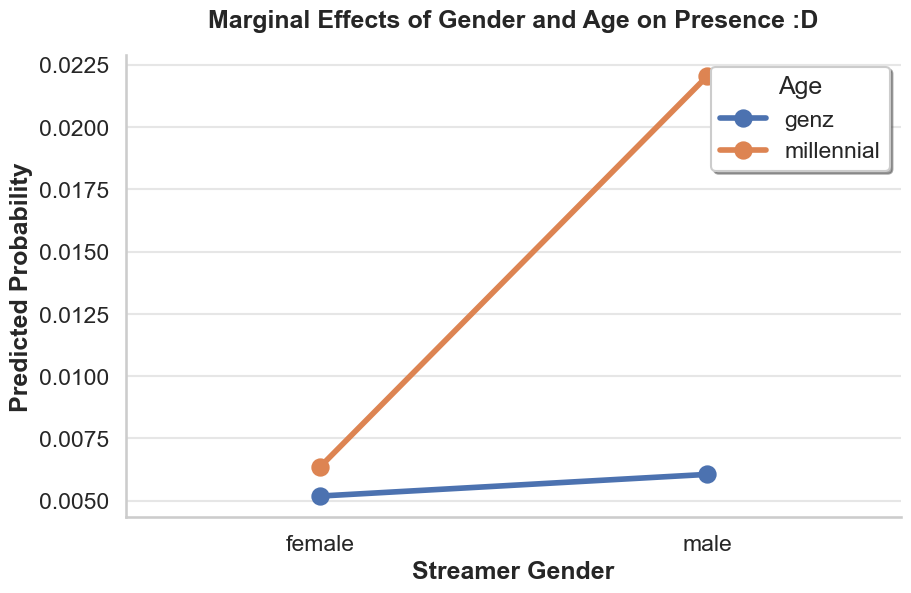

In [17]:
for emote in target_emotes:

    # --- B. Create Marginal Effects Plot ---
    demographics = df[['gender', 'genre', 'age', 'sentiment']].drop_duplicates()

    # 2. Predict (Ensure 'combos' or 'demographics' is actually used)
    # Based on your error, you need to make sure 'sentiment' is in this dataframe:
    demographics['prob'] = results.predict(demographics)
    
    # 3. Aggregate (mean) across the variable you are NOT plotting (genre)
    # This isolates the effect to just Gender and Age
    plot_data = demographics.groupby(['gender', 'age'])['prob'].mean().reset_index()
    
    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})
    
    # Using a pointplot to show the interaction lines clearly
    g = sns.pointplot(
        data=plot_data, 
        x="gender", 
        y="prob",
        hue='age'
    )
    
    # 3. Clean up the "UI" of the plot
    plt.title(f"Marginal Effects of Gender and Age on Presence {emote}", pad=20, fontweight='bold')
    plt.xlabel("Streamer Gender", fontweight='bold')
    plt.ylabel(f"Predicted Probability", fontweight='bold')
    plt.legend(title="Age", frameon=True, shadow=True, facecolor='white')
        
    # Remove top and right spines for a modern look
    sns.despine()
    safe_name = emote.replace("<3", "heart").replace(":)", "smile").replace(":(", "sad")
    plt.savefig(f"plot_gender_age_{safe_name}.png", dpi=300, bbox_inches='tight')    
    plt.show()

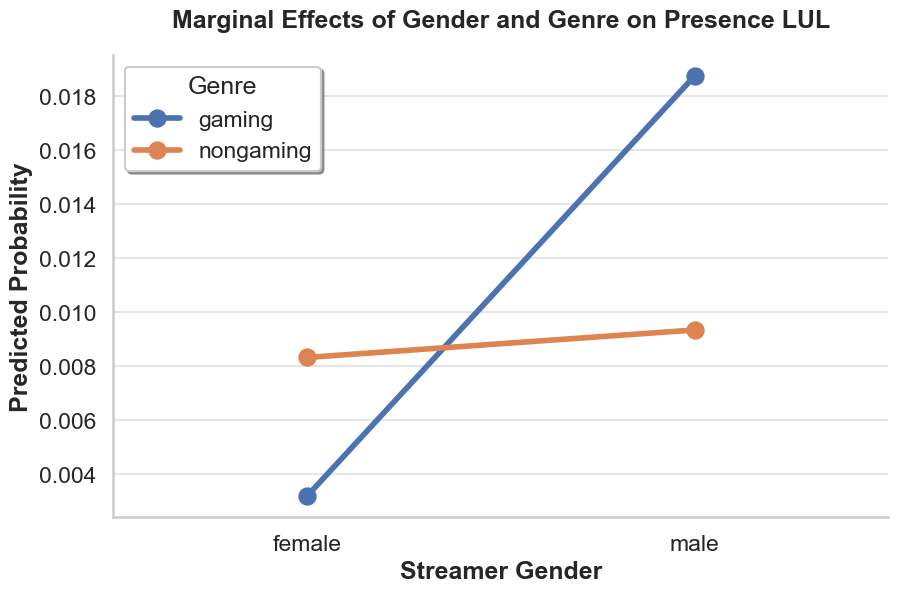

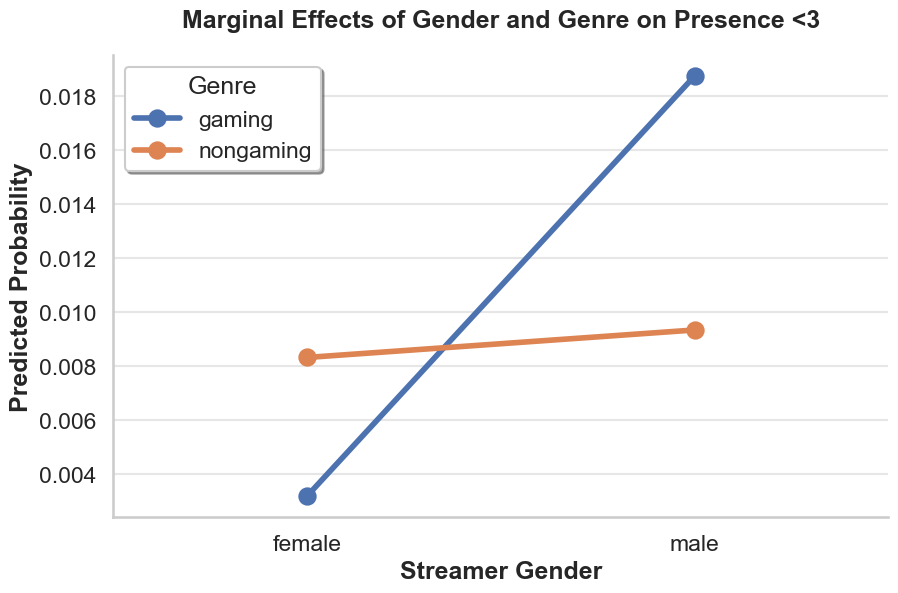

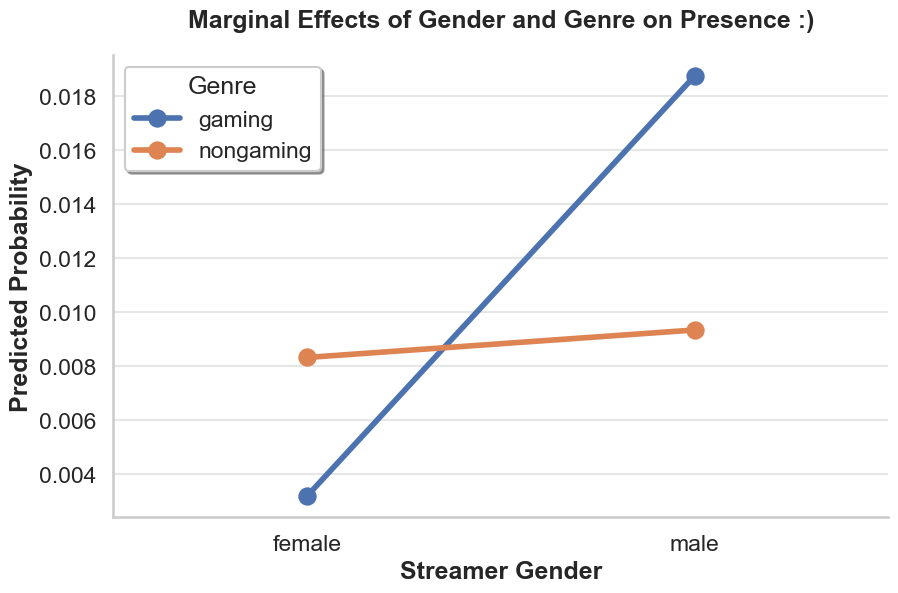

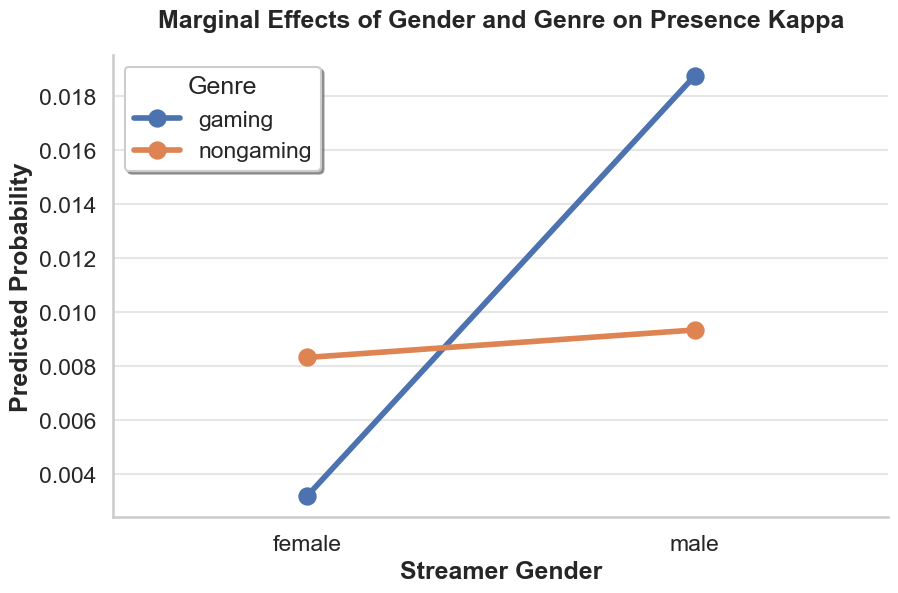

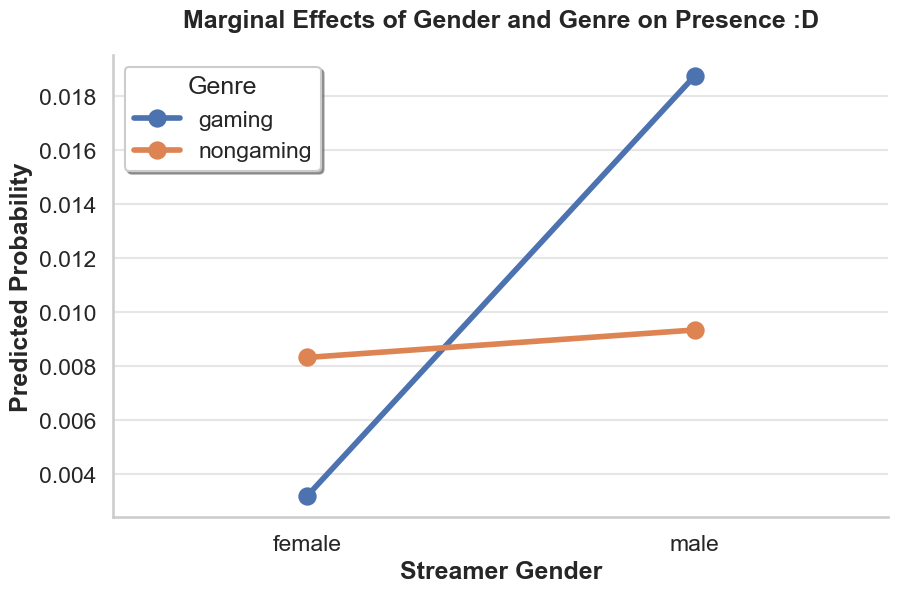

In [18]:
for emote in target_emotes:

    # --- B. Create Marginal Effects Plot ---
    demographics = df[['gender', 'genre', 'age', 'sentiment']].drop_duplicates()
    
    # If you want to hold sentiment constant at the average instead of using all values:
    # demographics['sentiment'] = df['sentiment'].mean() 

    # 2. Predict (Ensure 'combos' or 'demographics' is actually used)
    # Based on your error, you need to make sure 'sentiment' is in this dataframe:
    demographics['prob'] = results.predict(demographics)
    
    # 3. Aggregate (mean) across the variable you are NOT plotting (genre)
    # This isolates the effect to just Gender and Age
    plot_data = demographics.groupby(['gender', 'genre'])['prob'].mean().reset_index()
    
    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})
    
    # Using a pointplot to show the interaction lines clearly
    g = sns.pointplot(
        data=plot_data, 
        x="gender", 
        y="prob",
        hue='genre'
    )
    
    # 3. Clean up the "UI" of the plot
    plt.title(f"Marginal Effects of Gender and Genre on Presence {emote}", pad=20, fontweight='bold')
    plt.xlabel("Streamer Gender", fontweight='bold')
    plt.ylabel(f"Predicted Probability", fontweight='bold')
    plt.legend(title="Genre", frameon=True, shadow=True, facecolor='white')
        
    # Remove top and right spines for a modern look
    sns.despine()
    safe_name = emote.replace("<3", "heart").replace(":)", "smile").replace(":(", "sad")
    plt.savefig(f"plot_gender_genre_{safe_name}.png", dpi=300, bbox_inches='tight')    
    plt.show()

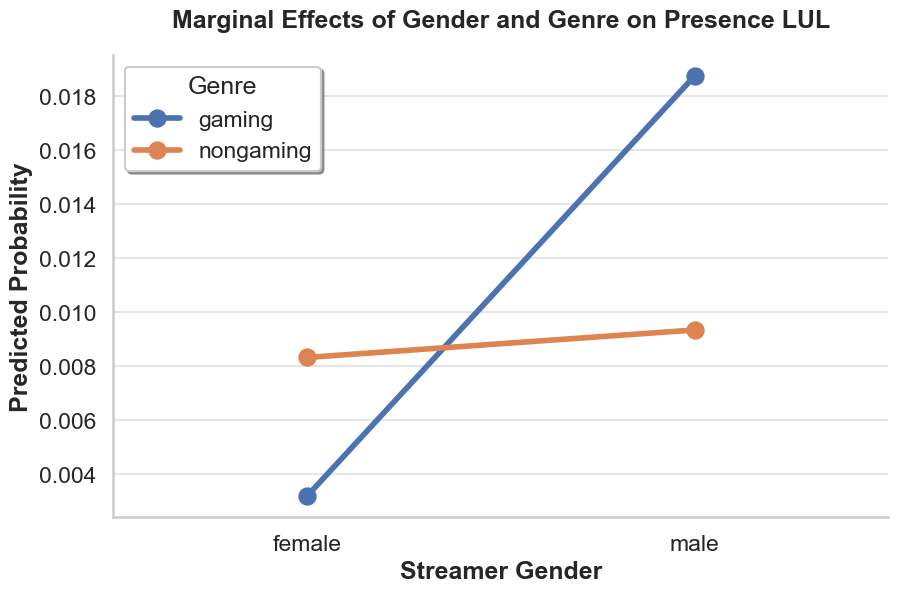

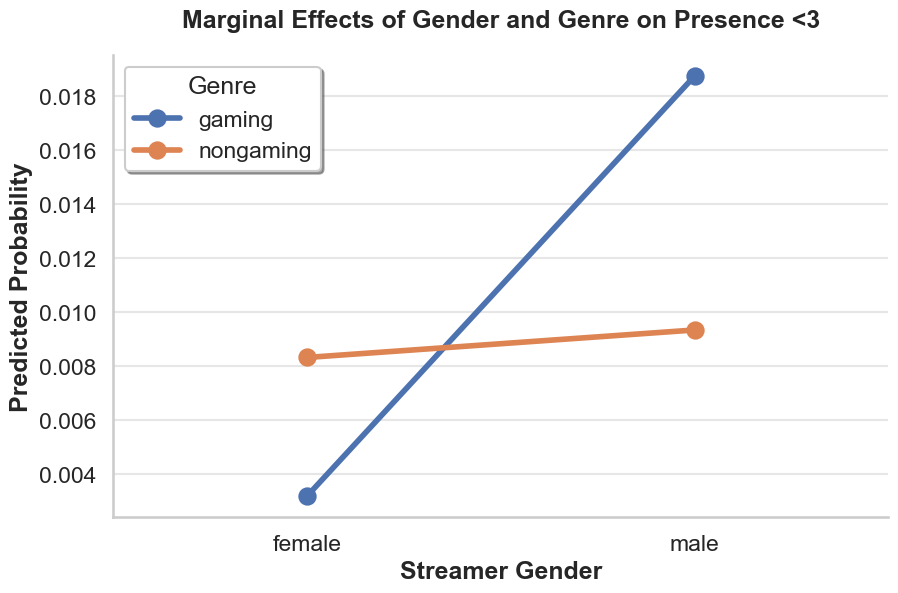

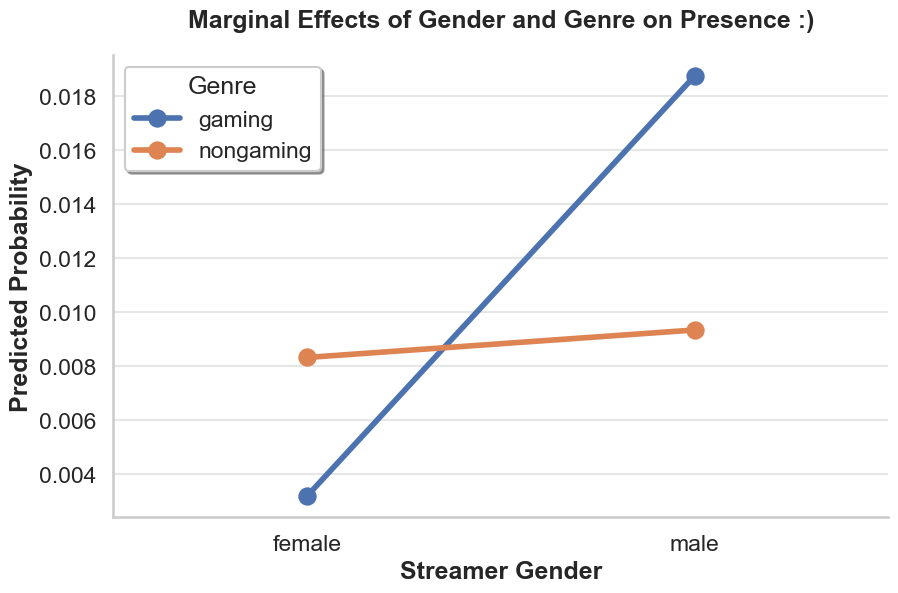

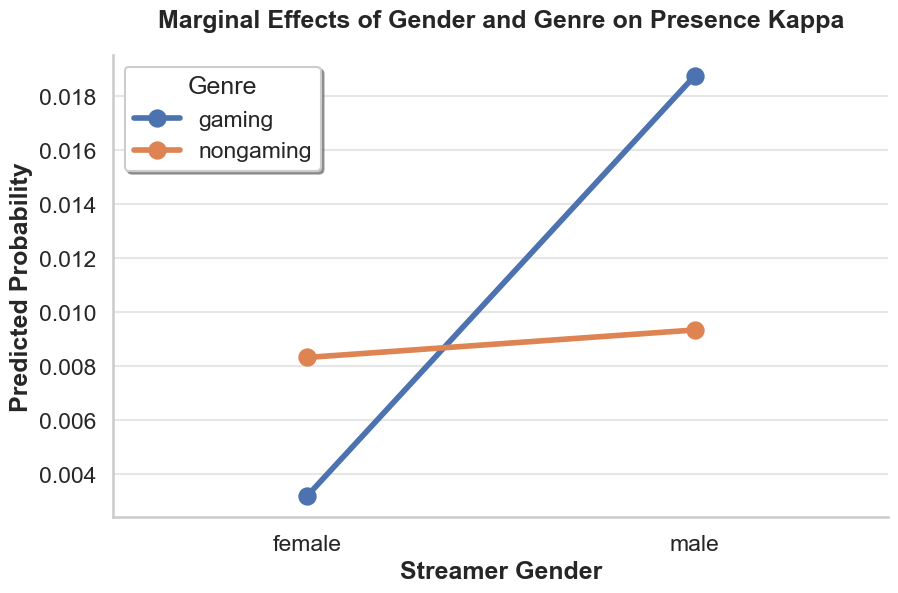

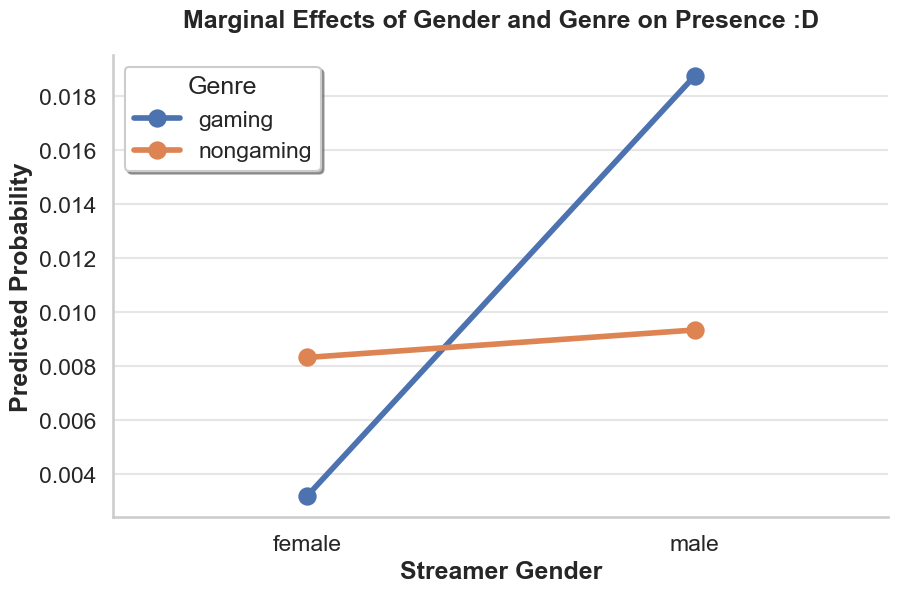

In [68]:
for emote in target_emotes:

    # --- B. Create Marginal Effects Plot ---
    demographics = df[['gender', 'genre', 'age', 'sentiment']].drop_duplicates()
    
    # If you want to hold sentiment constant at the average instead of using all values:
    # demographics['sentiment'] = df['sentiment'].mean() 

    # 2. Predict (Ensure 'combos' or 'demographics' is actually used)
    # Based on your error, you need to make sure 'sentiment' is in this dataframe:
    demographics['prob'] = results.predict(demographics)
    
    # 3. Aggregate (mean) across the variable you are NOT plotting (genre)
    # This isolates the effect to just Gender and Age
    plot_data = demographics.groupby(['gender', 'genre'])['prob'].mean().reset_index()
    
    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})
    
    # Using a pointplot to show the interaction lines clearly
    g = sns.pointplot(
        data=plot_data, 
        x="gender", 
        y="prob",
        hue='genre'
    )
    
    # 3. Clean up the "UI" of the plot
    plt.title(f"Marginal Effects of Gender and Genre on Presence {emote}", pad=20, fontweight='bold')
    plt.xlabel("Streamer Gender", fontweight='bold')
    plt.ylabel(f"Predicted Probability", fontweight='bold')
    plt.legend(title="Genre", frameon=True, shadow=True, facecolor='white')
        
    # Remove top and right spines for a modern look
    sns.despine()
    safe_name = emote.replace("<3", "heart").replace(":)", "smile").replace(":(", "sad")
    plt.savefig(f"plot_gender_genre_{safe_name}.png", dpi=300, bbox_inches='tight')    
    plt.show()

<Figure size 1000x600 with 0 Axes>

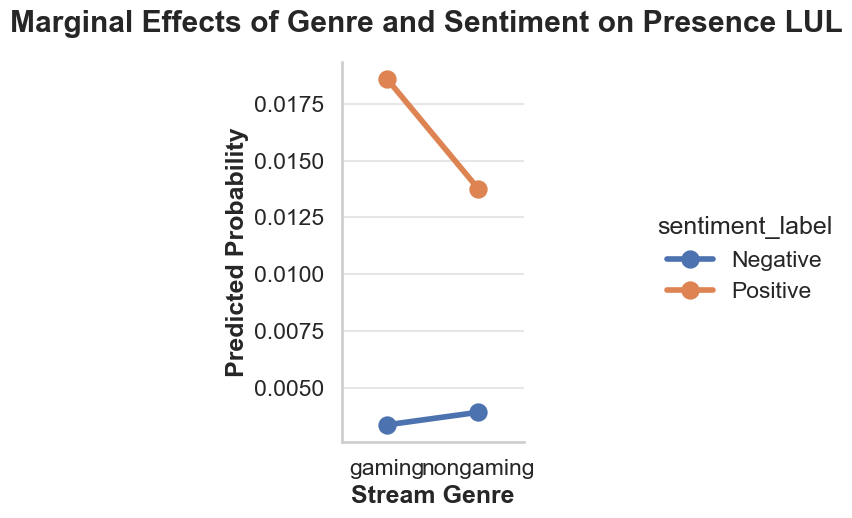

<Figure size 1000x600 with 0 Axes>

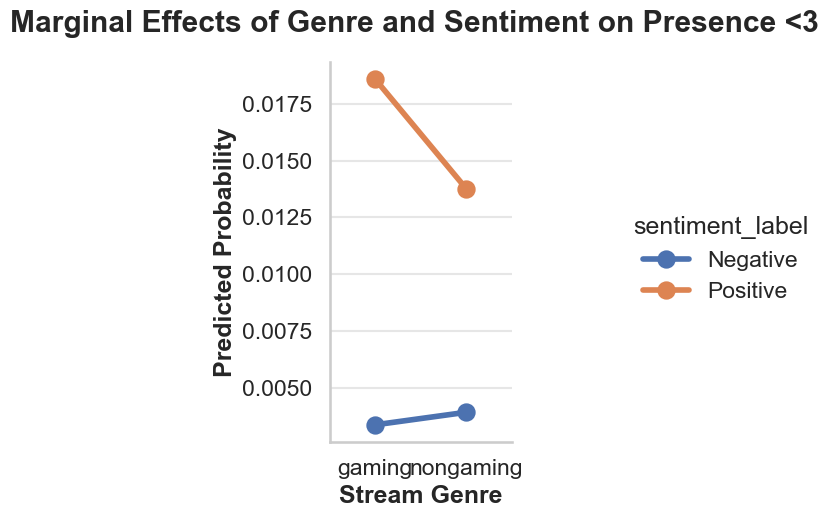

<Figure size 1000x600 with 0 Axes>

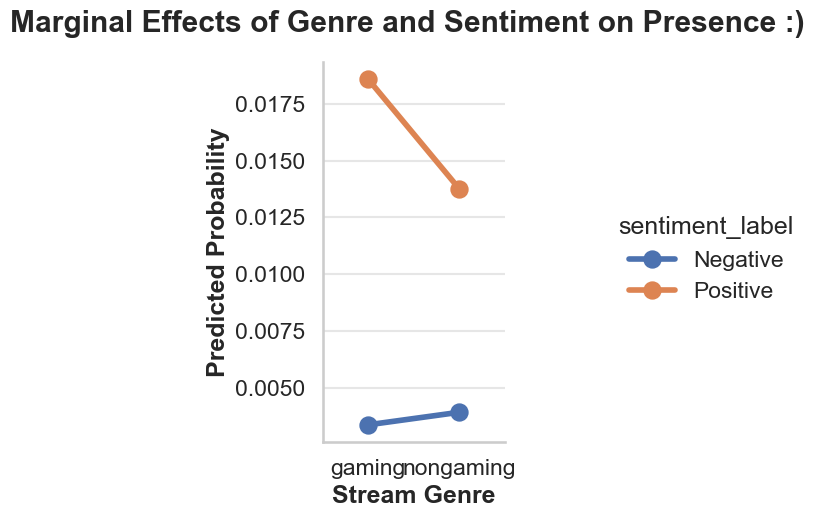

<Figure size 1000x600 with 0 Axes>

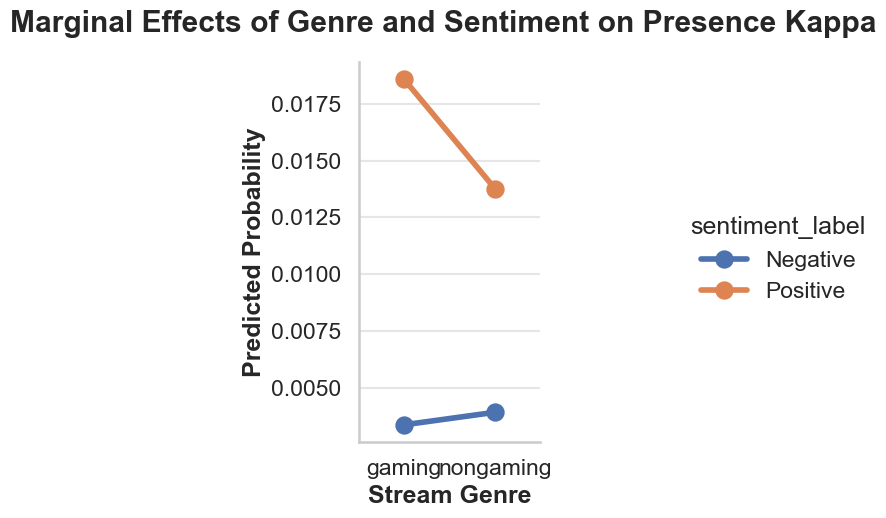

<Figure size 1000x600 with 0 Axes>

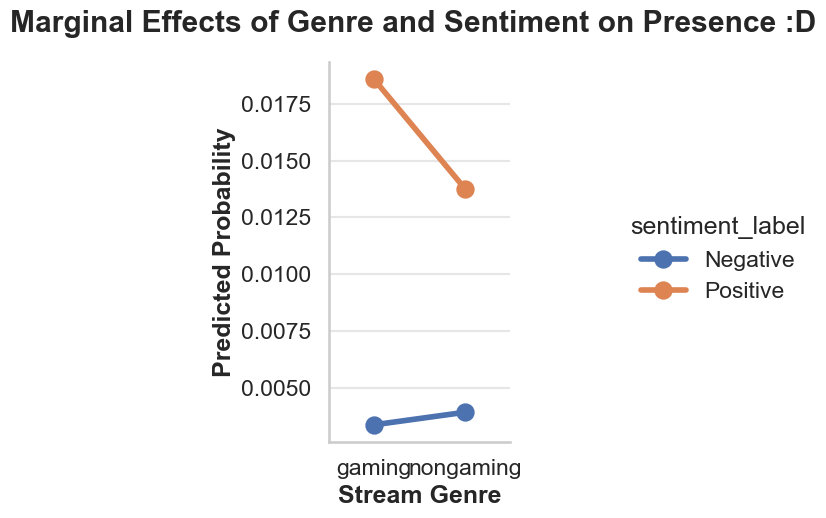

In [67]:
for emote in target_emotes:

    # --- B. Create Marginal Effects Plot ---
    demographics = df[['gender', 'genre', 'age', 'sentiment']].drop_duplicates()
    
    # If you want to hold sentiment constant at the average instead of using all values:
    # demographics['sentiment'] = df['sentiment'].mean() 

    # 2. Predict (Ensure 'combos' or 'demographics' is actually used)
    # Based on your error, you need to make sure 'sentiment' is in this dataframe:
    demographics['prob'] = results.predict(demographics)
    
    # 3. Aggregate (mean) across the variable you are NOT plotting (genre)
    # This isolates the effect to just Gender and Age
    plot_data = demographics.groupby(['sentiment', 'genre'])['prob'].mean().reset_index()
    plot_data['sentiment_label'] = plot_data['sentiment'].map({1: 'Positive', 0: 'Negative'})
    
    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})
    
    # Using a pointplot to show the interaction lines clearly
    g = sns.catplot(
        data=plot_data, 
        x="genre", 
        y="prob",
        hue='sentiment_label', 
        kind="point", capsize=.1, height=5, aspect=0.8
    )
    
    # 3. Clean up the "UI" of the plot
    g.set_axis_labels("Stream Genre", "Predicted Probability", fontweight='bold')
    g.fig.suptitle(f"Marginal Effects of Genre and Sentiment on Presence {emote}", y=1.05, fontweight='bold')
        
    # Remove top and right spines for a modern look
    sns.despine()
    safe_name = emote.replace("<3", "heart").replace(":)", "smile").replace(":(", "sad")
    plt.savefig(f"plot_genre_sent_{safe_name}.png", dpi=300, bbox_inches='tight')    
    plt.show()

In [4]:
for emote in target_emotes:

    # --- B. Create Marginal Effects Plot ---
    demographics = df[['gender', 'genre', 'age', 'sentiment']].drop_duplicates()
    
    # If you want to hold sentiment constant at the average instead of using all values:
    # demographics['sentiment'] = df['sentiment'].mean() 

    # 2. Predict (Ensure 'combos' or 'demographics' is actually used)
    # Based on your error, you need to make sure 'sentiment' is in this dataframe:
    demographics['prob'] = results.predict(demographics)
    
    # 3. Aggregate (mean) across the variable you are NOT plotting (genre)
    # This isolates the effect to just Gender and Age
    plot_data = demographics.groupby('genre')['prob'].mean().reset_index()
    
    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})
    
    # Using a pointplot to show the interaction lines clearly
    g = sns.pointplot(
        data=plot_data, 
        x="genre", 
        y="prob",
    )
    
    # 3. Clean up the "UI" of the plot
    plt.title(f"Marginal Effects of Genre on Presence {emote}", pad=20, fontweight='bold')
    plt.xlabel("Stream Genre", fontweight='bold')
    plt.ylabel(f"Predicted Probability", fontweight='bold')
        
    # Remove top and right spines for a modern look
    sns.despine()
    safe_name = emote.replace("<3", "heart").replace(":)", "smile").replace(":(", "sad")
    plt.savefig(f"plot_genre_{safe_name}.png", dpi=300, bbox_inches='tight')    
    plt.show()

NameError: name 'target_emotes' is not defined

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# STAP 1: Data laden & Variabelen als categorie definiëren
# ---------------------------------------------------------
# Vervang dit door jouw eigen dataframe (bv. pd.read_csv('jouw_data.csv'))
# Let op: zorg dat gender, age en genre handige labels hebben (bv. 'M'/'V', 'Jong'/'Oud')

# ---------------------------------------------------------
# STAP 2: Logistische Regressie Model Fitten (Voorbeeld: Blijdschap)
# ---------------------------------------------------------
# We gebruiken de '*' operator voor de volledige 3-weg interactie (inclusief hoofdeffecten)
model = smf.logit("target_present ~ C(sentiment) * gender * age * genre", data=df).fit()

# ---------------------------------------------------------
# STAP 3: Marginale Effecten & Contrasten Berekenen (Route B)
# ---------------------------------------------------------
# We berekenen de voorspelde kansen voor alle 8 combinaties (2x2x2)
# 'at' specificeert dat we de combinaties van deze drie variabelen willen
margins = model.get_margeff(at="all")

# Om alle 28 mogelijke paarsgewijze vergelijkingen tussen de 8 groepen te maken,
# gebruiken we de 't_test_pairwise' functie op het model.
# Eerst maken we de interactie-variabele expliciet in de data om makkelijk te contrasteren:
df["group"] = (
    df["gender"].astype(str)
    + "_"
    + df["age"].astype(str)
    + "_"
    + df["genre"].astype(str)
)
model_pairwise = smf.logit("sentiment ~ C(group) - 1", data=df).fit()

# Voer de paarsgewijze vergelijking uit
pairwise_results = model_pairwise.t_test_pairwise("C(goup)")

# ---------------------------------------------------------
# STAP 4: P-waardes corrigeren met Holm-Bonferroni
# ---------------------------------------------------------
# Haal de ongecorrigeerde p-waardes op uit de resultaten
pairwise_df = pairwise_results.result_frame

# Pas de Holm-Bonferroni correctie toe op de 28 vergelijkingen
from statsmodels.stats.multitest import multipletests

rejected, p_adjusted, _, _ = multipletests(
    pairwise_df["pvalue"], alpha=0.05, method="holm"
)

# Voeg de gecorrigeerde p-waardes toe aan je resultatenoverzicht
pairwise_df["pvalue_corrected"] = p_adjusted
pairwise_df["significant_na_correctie"] = rejected

# Toon alleen de relevante kolommen in je output
print(pairwise_df[["coef", "pvalue", "pvalue_corrected", "significant_na_correctie"]])


         Current function value: 0.071851
         Iterations: 35
Optimization terminated successfully.
         Current function value: 0.336146
         Iterations 6


/Users/anaconda3/envs/thesis/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ValueError: 'C(goup)' is not in list